In [12]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/safevense-vi-dataset/final_train_data_v3_READY.xlsx


In [13]:
!pip install transformers accelerate -q

import torch
print(f'✅ PyTorch: {torch.__version__}')
print(f'✅ CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'✅ GPU: {torch.cuda.get_device_name(0)}')
    print(f'✅ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')


✅ PyTorch: 2.6.0+cu124
✅ CUDA available: True
✅ GPU: Tesla T4
✅ GPU Memory: 14.7 GB


In [14]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_cosine_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported!')



✅ All libraries imported!


In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3: Configuration
# ═══════════════════════════════════════════════════════════════════════════════

class Config:
    # Model
    MODEL_NAME = "vinai/phobert-base-v2"
    NUM_LABELS = 3
    MAX_LENGTH = 256
    
    # Training
    BATCH_SIZE = 16
    GRADIENT_ACCUMULATION_STEPS = 2  # Effective batch = 32
    EPOCHS = 5
    LEARNING_RATE = 2e-5
    WEIGHT_DECAY = 0.01
    WARMUP_RATIO = 0.1
    
    # Optimization
    USE_CLASS_WEIGHTS = True
    LABEL_SMOOTHING = 0.1
    
    # Early stopping
    PATIENCE = 2
    
    # Seed
    SEED = 42
    
    # Device
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Kaggle Paths
    DATA_PATH = "/kaggle/input/safesense-training-data/final_train_data_v3_READY.xlsx"
    OUTPUT_DIR = "/kaggle/working"
    MODEL_SAVE_PATH = "/kaggle/working/phobert_toxic_model"

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(Config.SEED)

print('✅ Configuration set!')
print(f'🔧 Device: {Config.DEVICE}')
print(f'🔧 Model: {Config.MODEL_NAME}')
print(f'🔧 Batch Size: {Config.BATCH_SIZE} x {Config.GRADIENT_ACCUMULATION_STEPS} = {Config.BATCH_SIZE * Config.GRADIENT_ACCUMULATION_STEPS}')

✅ Configuration set!
🔧 Device: cuda
🔧 Model: vinai/phobert-base-v2
🔧 Batch Size: 16 x 2 = 32


In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4: Find & Load Data
# ═══════════════════════════════════════════════════════════════════════════════

print("📂 FINDING DATA FILE...")
print("="*60)

input_path = "/kaggle/input"
data_path = None

if os.path.exists(input_path):
    for dataset in os.listdir(input_path):
        dataset_path = os.path.join(input_path, dataset)
        print(f"\n📁 {dataset}/")
        if os.path.isdir(dataset_path):
            for file in os.listdir(dataset_path):
                file_path = os.path.join(dataset_path, file)
                size = os.path.getsize(file_path) / 1024 / 1024
                print(f"   📄 {file} ({size:.2f} MB)")
                if 'READY' in file and file.endswith('.xlsx'):
                    data_path = file_path
                elif file.endswith('.xlsx') and data_path is None:
                    data_path = file_path

if data_path:
    Config.DATA_PATH = data_path
    print(f"\n✅ Using: {data_path}")
else:
    print("❌ No data file found!")

📂 FINDING DATA FILE...

📁 safevense-vi-dataset/
   📄 final_train_data_v3_READY.xlsx (1.11 MB)

✅ Using: /kaggle/input/safevense-vi-dataset/final_train_data_v3_READY.xlsx


In [17]:
import pandas as pd
import numpy as np

print("="*80)
print("📊 LOADING & PREPROCESSING DATA")
print("="*80)

# 1. Load Data
if Config.DATA_PATH.endswith('.xlsx'):
    df = pd.read_excel(Config.DATA_PATH)
else:
    df = pd.read_csv(Config.DATA_PATH)

# 2. Identify Columns
text_col = 'training_text' if 'training_text' in df.columns else 'text'
label_col = 'label'

# 3. FIX TYPE ERROR: Ép kiểu label về numeric và xử lý dữ liệu thiếu
# Bước này chuyển các giá trị '0', '1' (string) về 0, 1 (int) và loại bỏ lỗi so sánh
df[label_col] = pd.to_numeric(df[label_col], errors='coerce')

# Loại bỏ các dòng bị trống (NaN) ở cả cột Text và Label
initial_len = len(df)
df = df.dropna(subset=[text_col, label_col])
df[label_col] = df[label_col].astype(int) # Chuyển hẳn về kiểu int

if len(df) < initial_len:
    print(f"⚠️ Removed {initial_len - len(df)} samples with missing values.")

print(f"\n📂 Final Dataset Size: {len(df)} samples")
print(f"📂 Columns: {df.columns.tolist()}")
print(f"📝 Text column: {text_col} | Label column: {label_col}")

# 4. Check word segmentation (Kiểm tra dấu gạch dưới _)
sample_text = str(df[text_col].iloc[0])
underscore_count = sample_text.count('_')
print(f"\n🔍 WORD SEGMENTATION CHECK:")
print(f"   Sample text: {sample_text[:100]}...")
if underscore_count > 0:
    print(f"   ✅ Data is PRE-SEGMENTED (Underscores: {underscore_count})")
    print(f"   👉 No need to run RDRSegmenter during training.")
else:
    print(f"   ⚠️ Data is NOT segmented. Remember to use VnCoreNLP/PyVi!")

# 5. Label distribution
print(f"\n📊 LABEL DISTRIBUTION:")
label_counts = df[label_col].value_counts().sort_index()
label_names = {0: 'Clean', 1: 'Toxic', 2: 'Hate'}

# Tạo bảng thống kê nhỏ
stats_data = []
for label, count in label_counts.items():
    pct = (count / len(df)) * 100
    name = label_names.get(int(label), 'Unknown')
    stats_data.append([label, name, count, f"{pct:.2f}%"])
    print(f"   Label {int(label)} ({name}): {count} samples ({pct:.2f}%)")

# 6. Check Balance
balance_ratio = label_counts.max() / label_counts.min()
print(f"\n⚖️ Balance ratio: {balance_ratio:.2f}x")
if balance_ratio > 2:
    print("   💡 Tip: Consider using Class Weights or Oversampling to handle imbalance.")

📊 LOADING & PREPROCESSING DATA
⚠️ Removed 6 samples with missing values.

📂 Final Dataset Size: 6285 samples
📂 Columns: ['training_text', 'text_raw', 'label', 'note', 'source_file', 'labeler', 'has_teencode', 'confidence', 'sampling_strategy', 'raw_comment', 'raw_title', 'training_text_original']
📝 Text column: training_text | Label column: label

🔍 WORD SEGMENTATION CHECK:
   Sample text: boy phố mới nhú hay sao mà mặt ông cháu nào cũng non_choẹt vậy ?_ </s> tệ_nạn xã_hội tương_lai đấy c...
   ✅ Data is PRE-SEGMENTED (Underscores: 8)
   👉 No need to run RDRSegmenter during training.

📊 LABEL DISTRIBUTION:
   Label 0 (Clean): 2795 samples (44.47%)
   Label 1 (Toxic): 1647 samples (26.21%)
   Label 2 (Hate): 1843 samples (29.32%)

⚖️ Balance ratio: 1.70x


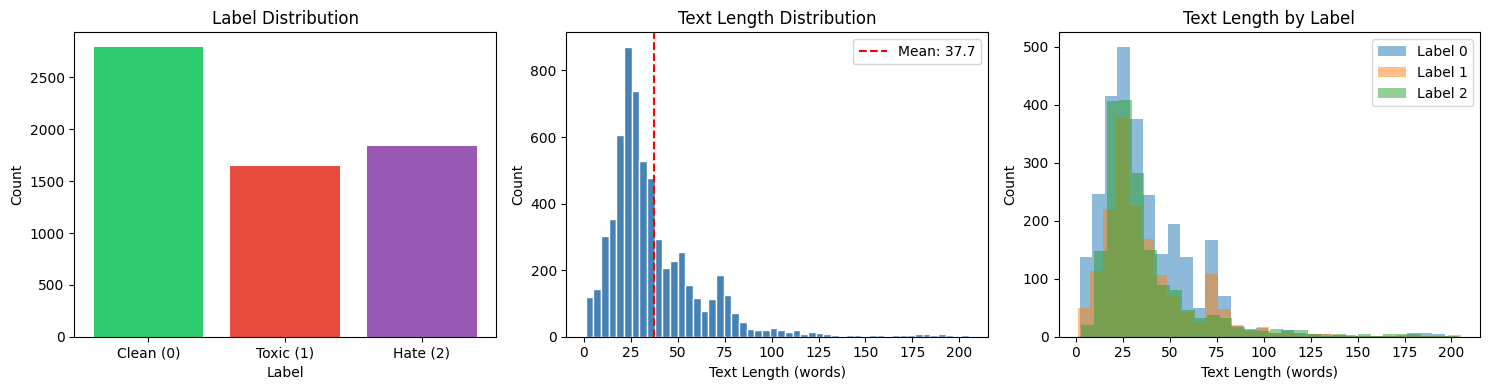

In [18]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6: Visualize Data
# ═══════════════════════════════════════════════════════════════════════════════

df['text_length'] = df[text_col].astype(str).str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colors = ['#2ecc71', '#e74c3c', '#9b59b6']
axes[0].bar(label_counts.index, label_counts.values, color=colors)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].set_title('Label Distribution')
axes[0].set_xticks([0, 1, 2])
axes[0].set_xticklabels(['Clean (0)', 'Toxic (1)', 'Hate (2)'])

axes[1].hist(df['text_length'], bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(df['text_length'].mean(), color='red', linestyle='--', label=f'Mean: {df["text_length"].mean():.1f}')
axes[1].set_xlabel('Text Length (words)')
axes[1].set_ylabel('Count')
axes[1].set_title('Text Length Distribution')
axes[1].legend()

for label in sorted(df[label_col].unique()):
    subset = df[df[label_col] == label]['text_length']
    axes[2].hist(subset, bins=30, alpha=0.5, label=f'Label {int(label)}')
axes[2].set_xlabel('Text Length (words)')
axes[2].set_ylabel('Count')
axes[2].set_title('Text Length by Label')
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{Config.OUTPUT_DIR}/data_distribution.png', dpi=150)
plt.show()

In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7: Prepare Data
# ═══════════════════════════════════════════════════════════════════════════════

print("="*80)
print("🔧 PREPARING DATA")
print("="*80)

texts = df[text_col].fillna('').astype(str).tolist()
labels = df[label_col].astype(int).tolist()

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels,
    test_size=0.15,
    random_state=Config.SEED,
    stratify=labels
)

print(f"📊 Train: {len(train_texts)} | Val: {len(val_texts)}")
print("✅ Data prepared!")


🔧 PREPARING DATA
📊 Train: 5342 | Val: 943
✅ Data prepared!


In [20]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8: Load Tokenizer & Create Dataset (NO SEGMENTATION NEEDED!)
# ═══════════════════════════════════════════════════════════════════════════════

print("📥 Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(Config.MODEL_NAME)
print(f"✅ Tokenizer loaded: {Config.MODEL_NAME}")

# NOTE: Data đã được segment sẵn trong file READY
# KHÔNG CẦN segment trong Dataset class!

class ToxicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Text đã được segment sẵn, chỉ cần tokenize
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

train_dataset = ToxicDataset(train_texts, train_labels, tokenizer, Config.MAX_LENGTH)
val_dataset = ToxicDataset(val_texts, val_labels, tokenizer, Config.MAX_LENGTH)

print(f"✅ Train dataset: {len(train_dataset)} | Val dataset: {len(val_dataset)}")
print(f"✅ Word segmentation: PRE-APPLIED (no runtime segmentation needed)")

📥 Loading tokenizer...


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer loaded: vinai/phobert-base-v2
✅ Train dataset: 5342 | Val dataset: 943
✅ Word segmentation: PRE-APPLIED (no runtime segmentation needed)


In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 9: Create DataLoaders & Class Weights
# ═══════════════════════════════════════════════════════════════════════════════

# DataLoaders - num_workers=0 để tránh lỗi multiprocessing trên Kaggle
train_loader = DataLoader(
    train_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=Config.BATCH_SIZE * 2,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"✅ Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=train_labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(Config.DEVICE)

print(f"⚖️ Class weights: {class_weights.cpu().numpy()}")

✅ Train batches: 334 | Val batches: 30
⚖️ Class weights: [0.7494388 1.2719047 1.1370796]


In [22]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 10: Load Model & Setup Training
# ═══════════════════════════════════════════════════════════════════════════════

print("="*80)
print("📥 LOADING MODEL")
print("="*80)

model = AutoModelForSequenceClassification.from_pretrained(
    Config.MODEL_NAME,
    num_labels=Config.NUM_LABELS
)
model.to(Config.DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Model loaded: {total_params:,} parameters")

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=Config.LABEL_SMOOTHING
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=Config.LEARNING_RATE,
    weight_decay=Config.WEIGHT_DECAY
)

total_steps = len(train_loader) * Config.EPOCHS // Config.GRADIENT_ACCUMULATION_STEPS
warmup_steps = int(total_steps * Config.WARMUP_RATIO)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"✅ Optimizer: AdamW (lr={Config.LEARNING_RATE})")
print(f"✅ Scheduler: Cosine warmup ({warmup_steps}/{total_steps} steps)")

📥 LOADING MODEL


2025-12-30 04:50:58.968312: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767070259.215110      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767070259.287293      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/phobert-base-v2 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model loaded: 135,000,579 parameters
✅ Optimizer: AdamW (lr=2e-05)
✅ Scheduler: Cosine warmup (83/835 steps)


In [23]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 11: Training Functions
# ═══════════════════════════════════════════════════════════════════════════════

def train_epoch(model, dataloader, optimizer, scheduler, criterion, device, accumulation_steps):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    
    progress_bar = tqdm(dataloader, desc="Training", leave=False)
    optimizer.zero_grad()
    
    for step, batch in enumerate(progress_bar):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels) / accumulation_steps
        loss.backward()
        
        if (step + 1) % accumulation_steps == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
        
        total_loss += loss.item() * accumulation_steps
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        progress_bar.set_postfix({'loss': f'{loss.item() * accumulation_steps:.4f}'})
    
    return total_loss / len(dataloader), f1_score(all_labels, all_preds, average='macro')


def eval_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_probs = [], [], []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)
            
            total_loss += loss.item()
            probs = torch.softmax(outputs.logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    metrics = {
        'loss': total_loss / len(dataloader),
        'f1_macro': f1_score(all_labels, all_preds, average='macro'),
        'f1_weighted': f1_score(all_labels, all_preds, average='weighted'),
        'accuracy': accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, average='macro'),
        'recall': recall_score(all_labels, all_preds, average='macro')
    }
    
    return metrics, all_preds, all_labels, all_probs

print("✅ Training functions defined!")

✅ Training functions defined!


In [24]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 12: Training Loop
# ═══════════════════════════════════════════════════════════════════════════════

print("="*80)
print("🏋️ STARTING TRAINING")
print("="*80)

history = {'train_loss': [], 'train_f1': [], 'val_loss': [], 'val_f1': [], 'val_accuracy': []}
best_f1 = 0
best_epoch = 0
patience_counter = 0
best_model_state = None

for epoch in range(Config.EPOCHS):
    print(f"\n{'='*60}")
    print(f"📅 Epoch {epoch + 1}/{Config.EPOCHS}")
    print(f"{'='*60}")
    
    train_loss, train_f1 = train_epoch(
        model, train_loader, optimizer, scheduler, criterion,
        Config.DEVICE, Config.GRADIENT_ACCUMULATION_STEPS
    )
    
    val_metrics, val_preds, val_true, val_probs = eval_epoch(
        model, val_loader, criterion, Config.DEVICE
    )
    
    history['train_loss'].append(train_loss)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_metrics['loss'])
    history['val_f1'].append(val_metrics['f1_macro'])
    history['val_accuracy'].append(val_metrics['accuracy'])
    
    print(f"\n📊 Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f}")
    print(f"📊 Val Loss: {val_metrics['loss']:.4f} | Val F1: {val_metrics['f1_macro']:.4f} | Val Acc: {val_metrics['accuracy']:.4f}")
    
    if val_metrics['f1_macro'] > best_f1:
        best_f1 = val_metrics['f1_macro']
        best_epoch = epoch + 1
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        print(f"✅ New best F1: {best_f1:.4f}")
    else:
        patience_counter += 1
        print(f"⚠️ No improvement. Patience: {patience_counter}/{Config.PATIENCE}")
    
    if patience_counter >= Config.PATIENCE:
        print(f"\n🛑 Early stopping at epoch {epoch + 1}")
        break

if best_model_state:
    model.load_state_dict(best_model_state)

print(f"\n{'='*60}")
print(f"🏆 TRAINING COMPLETE! Best F1: {best_f1:.4f} at epoch {best_epoch}")
print(f"{'='*60}")

🏋️ STARTING TRAINING

📅 Epoch 1/5


Training:   0%|          | 0/334 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]


📊 Train Loss: 0.9884 | Train F1: 0.5137
📊 Val Loss: 0.8653 | Val F1: 0.6684 | Val Acc: 0.6702
✅ New best F1: 0.6684

📅 Epoch 2/5


...

Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]


📊 Train Loss: 0.5529 | Train F1: 0.8634
📊 Val Loss: 0.6849 | Val F1: 0.7961 | Val Acc: 0.8028
✅ New best F1: 0.7961

📅 Epoch 5/5


Training:   0%|          | 0/334 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]


📊 Train Loss: 0.5119 | Train F1: 0.8942
📊 Val Loss: 0.6875 | Val F1: 0.7937 | Val Acc: 0.7996
⚠️ No improvement. Patience: 1/2

🏆 TRAINING COMPLETE! Best F1: 0.7961 at epoch 4


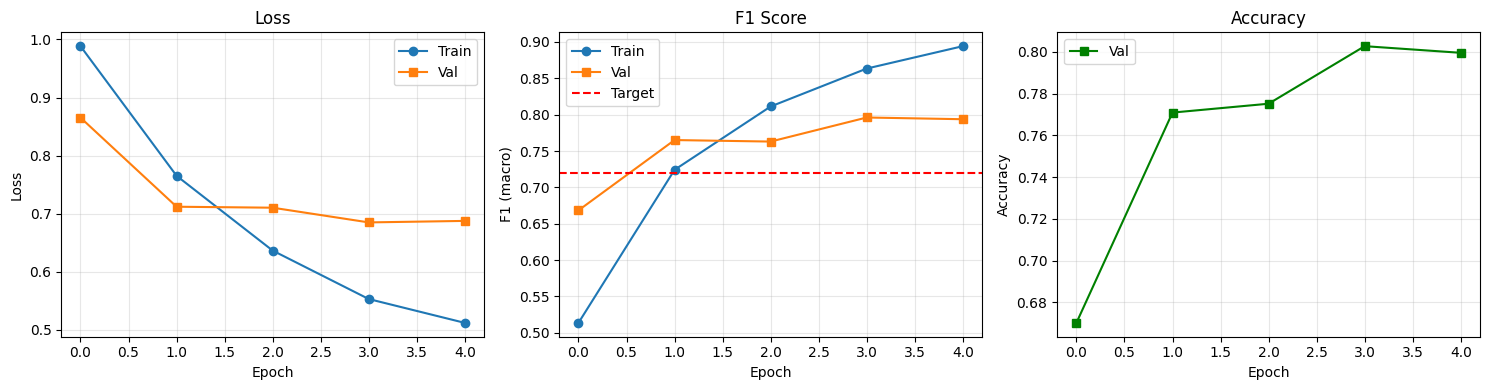

In [25]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 13: Plot Training History
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], label='Train', marker='o')
axes[0].plot(history['val_loss'], label='Val', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_f1'], label='Train', marker='o')
axes[1].plot(history['val_f1'], label='Val', marker='s')
axes[1].axhline(y=0.72, color='r', linestyle='--', label='Target')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 (macro)')
axes[1].set_title('F1 Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['val_accuracy'], label='Val', marker='s', color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].set_title('Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{Config.OUTPUT_DIR}/training_history.png', dpi=150)
plt.show()


📊 FINAL EVALUATION


Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]


🎯 FINAL METRICS:
   F1 (macro): 0.7937
   F1 (weighted): 0.8012
   Accuracy: 0.7996
   Precision: 0.7920
   Recall: 0.7988

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       Clean       0.86      0.80      0.83       419
       Toxic       0.69      0.80      0.74       247
        Hate       0.82      0.79      0.80       277

    accuracy                           0.80       943
   macro avg       0.79      0.80      0.79       943
weighted avg       0.81      0.80      0.80       943



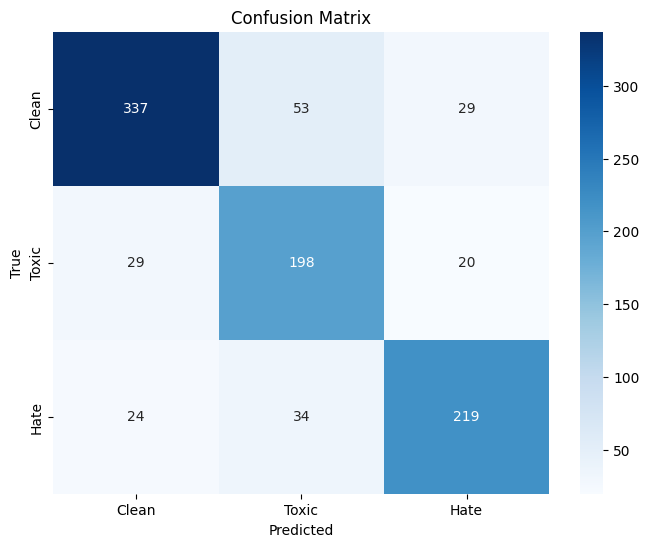

In [26]:

# ═══════════════════════════════════════════════════════════════════════════════
# CELL 14: Final Evaluation & Confusion Matrix
# ═══════════════════════════════════════════════════════════════════════════════

print("="*80)
print("📊 FINAL EVALUATION")
print("="*80)

final_metrics, final_preds, final_true, final_probs = eval_epoch(
    model, val_loader, criterion, Config.DEVICE
)

print(f"\n🎯 FINAL METRICS:")
print(f"   F1 (macro): {final_metrics['f1_macro']:.4f}")
print(f"   F1 (weighted): {final_metrics['f1_weighted']:.4f}")
print(f"   Accuracy: {final_metrics['accuracy']:.4f}")
print(f"   Precision: {final_metrics['precision']:.4f}")
print(f"   Recall: {final_metrics['recall']:.4f}")

print(f"\n📋 CLASSIFICATION REPORT:")
print(classification_report(final_true, final_preds, target_names=['Clean', 'Toxic', 'Hate']))

cm = confusion_matrix(final_true, final_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Clean', 'Toxic', 'Hate'],
            yticklabels=['Clean', 'Toxic', 'Hate'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig(f'{Config.OUTPUT_DIR}/confusion_matrix.png', dpi=150)
plt.show()


In [27]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 15: Error Analysis & Export
# ═══════════════════════════════════════════════════════════════════════════════

print("="*80)
print("🔍 ERROR ANALYSIS")
print("="*80)

label_names_map = {0: 'Clean', 1: 'Toxic', 2: 'Hate'}

error_data = []
for i, (text, true_label, pred_label, probs) in enumerate(zip(val_texts, final_true, final_preds, final_probs)):
    is_error = true_label != pred_label
    error_data.append({
        'id': i + 1,
        'text': text,
        'true_label': int(true_label),
        'true_label_name': label_names_map[int(true_label)],
        'pred_label': int(pred_label),
        'pred_label_name': label_names_map[int(pred_label)],
        'is_error': is_error,
        'error_type': f"{int(true_label)}→{int(pred_label)}" if is_error else 'Correct',
        'confidence': float(probs[pred_label]),
        'conf_clean': float(probs[0]),
        'conf_toxic': float(probs[1]),
        'conf_hate': float(probs[2])
    })

df_results = pd.DataFrame(error_data)
df_errors = df_results[df_results['is_error'] == True].copy()

total_errors = len(df_errors)
print(f"\n📊 Errors: {total_errors} / {len(df_results)} ({total_errors/len(df_results)*100:.1f}%)")

print(f"\n📊 ERROR BREAKDOWN:")
for et, cnt in df_errors['error_type'].value_counts().items():
    print(f"   {et}: {cnt}")

# Save errors to Excel
error_file = f'{Config.OUTPUT_DIR}/model_errors.xlsx'
df_errors.to_excel(error_file, index=False)
print(f"\n💾 Errors saved: {error_file}")

# Show top errors
print(f"\n🔥 TOP 10 HIGH-CONFIDENCE ERRORS:")
high_conf_errors = df_errors.sort_values('confidence', ascending=False).head(10)
for idx, row in high_conf_errors.iterrows():
    print(f"\n[{row['error_type']}] Conf: {row['confidence']:.2%}")
    print(f"   {row['text'][:80]}...")


🔍 ERROR ANALYSIS

📊 Errors: 189 / 943 (20.0%)

📊 ERROR BREAKDOWN:
   0→1: 53
   2→1: 34
   1→0: 29
   0→2: 29
   2→0: 24
   1→2: 20

💾 Errors saved: /kaggle/working/model_errors.xlsx

🔥 TOP 10 HIGH-CONFIDENCE ERRORS:

[1→2] Conf: 93.24%
   dấu chấm_hết cho tiktoker đớp 40 triệu tiền từ_thiện </s> muốn làm từ_thiện thì ...

[1→2] Conf: 93.24%
   cặp đôi_ninh - dương gây_sốt khi bán 2,8 tr / vé cho fan meeting . </s> cái lồn ...

[0→2] Conf: 92.90%
   cặp đôi_ninh - dương gây_sốt khi bán 2,8 tr / vé cho fan meeting . </s> xã_hội b...

[1→2] Conf: 92.79%
   cặp đôi_ninh - dương gây_sốt khi bán 2,8 tr / vé cho fan meeting . </s> mày sai ...

[0→2] Conf: 92.73%
   vậy là chúng_ta đã kết_thúc chuỗi ngày tự_do yêu nhau chuyển sang cuộc_sống hôn_...

[1→2] Conf: 92.70%
   tiktoker quấy_rối nơi công_cộng và scam tiền ( mr bích việt_nam ) </s> a cn là c...

[0→2] Conf: 92.52%
   đứa con từ trên trời rơi xuống | hai anh_em phần 1022 | phim tình_cảm hài_hước g...

[2→1] Conf: 92.28%
   <person> my

In [28]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 16: Save Model
# ═══════════════════════════════════════════════════════════════════════════════

print("="*80)
print("💾 SAVING MODEL")
print("="*80)

os.makedirs(Config.MODEL_SAVE_PATH, exist_ok=True)

model.save_pretrained(Config.MODEL_SAVE_PATH)
tokenizer.save_pretrained(Config.MODEL_SAVE_PATH)

import json
config_dict = {
    'model_name': Config.MODEL_NAME,
    'num_labels': Config.NUM_LABELS,
    'max_length': Config.MAX_LENGTH,
    'best_f1': best_f1,
    'best_epoch': best_epoch,
    'final_metrics': final_metrics,
    'data_file': Config.DATA_PATH,
    'word_segmentation': 'PRE-APPLIED'
}
with open(f'{Config.MODEL_SAVE_PATH}/training_config.json', 'w') as f:
    json.dump(config_dict, f, indent=2, default=str)

pd.DataFrame(history).to_csv(f'{Config.MODEL_SAVE_PATH}/training_history.csv', index=False)

print(f"\n✅ Model saved to: {Config.MODEL_SAVE_PATH}")

print(f"\n📁 OUTPUT FILES:")
for f in os.listdir(Config.OUTPUT_DIR):
    fpath = os.path.join(Config.OUTPUT_DIR, f)
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath) / 1024 / 1024
        print(f"   {f} ({size:.2f} MB)")


💾 SAVING MODEL

✅ Model saved to: /kaggle/working/phobert_toxic_model

📁 OUTPUT FILES:
   data_distribution.png (0.06 MB)
   confusion_matrix.png (0.04 MB)
   model_errors.xlsx (0.04 MB)
   training_history.png (0.10 MB)


In [41]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 17: Test Inference
# ═══════════════════════════════════════════════════════════════════════════════

print("="*80)
print("🧪 TEST INFERENCE")
print("="*80)

# NOTE: Khi inference với text MỚI, cần segment trước!
# Nhưng với test samples đơn giản, có thể bỏ qua

def predict(text, model, tokenizer, device):
    model.eval()
    encoding = tokenizer(text, max_length=Config.MAX_LENGTH, padding='max_length', 
                        truncation=True, return_tensors='pt')
    with torch.no_grad():
        outputs = model(encoding['input_ids'].to(device), encoding['attention_mask'].to(device))
        probs = torch.softmax(outputs.logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()
    return pred, probs[0].cpu().numpy()

test_samples = [
    "video hay quá, cảm_ơn bạn",
    "thằng ngu, mày biết gì",
    "đồ con chó, cút đi",
    "sản_phẩm chất vcl",
    "hôm qua có thằng kia kêu tui là bắc kỳ",
    "gặp t là t giết nó luôn rồi",
    "bọn bắc_kỳ toàn lừa_đảo",
    "học_sinh giỏi bú_fame"
]

label_names_list = ['Clean', 'Toxic', 'Hate']
print("\n🔮 PREDICTIONS:")
for text in test_samples:
    pred, probs = predict(text, model, tokenizer, Config.DEVICE)
    print(f"\n📝 {text}")
    print(f"   → {label_names_list[pred]} ({probs[pred]:.2%})")

🧪 TEST INFERENCE

🔮 PREDICTIONS:

📝 video hay quá, cảm_ơn bạn
   → Clean (86.57%)

📝 thằng ngu, mày biết gì
   → Toxic (85.58%)

📝 đồ con chó, cút đi
   → Hate (91.69%)

📝 sản_phẩm chất vcl
   → Toxic (64.17%)

📝 hôm qua có thằng kia kêu tui là bắc kỳ
   → Clean (62.70%)

📝 gặp t là t giết nó luôn rồi
   → Hate (71.04%)

📝 bọn bắc_kỳ toàn lừa_đảo
   → Hate (90.77%)

📝 học_sinh giỏi bú_fame
   → Toxic (86.26%)


In [30]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 18: Summary
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("🏆 TRAINING SUMMARY")
print("="*80)

print(f"""
📊 DATASET: {len(texts)} samples (Train: {len(train_texts)} | Val: {len(val_texts)})
   Word Segmentation: PRE-APPLIED ✅

🔧 MODEL: {Config.MODEL_NAME}
   Parameters: {total_params:,}
   Max Length: {Config.MAX_LENGTH}

📈 TRAINING:
   Epochs: {len(history['train_loss'])} (best at {best_epoch})
   Batch: {Config.BATCH_SIZE} x {Config.GRADIENT_ACCUMULATION_STEPS}

🎯 RESULTS:
   Best F1 (macro): {best_f1:.4f}
   Final Accuracy: {final_metrics['accuracy']:.4f}
   Errors: {total_errors} ({total_errors/len(df_results)*100:.1f}%)

💾 OUTPUT: {Config.OUTPUT_DIR}
   - phobert_toxic_model/
   - training_history.png
   - confusion_matrix.png
   - model_errors.xlsx

{'✅ TARGET ACHIEVED!' if best_f1 >= 0.72 else '⚠️ Target (0.72) not reached'}
""")

print("="*80)
print("✅ NOTEBOOK COMPLETE!")
print("="*80) 
print("\n📥 To download model: Click 'Output' tab → Download files")
print("\n⚠️ LƯU Ý: Khi inference với text MỚI, cần segment trước bằng underthesea!")
print("   from underthesea import word_tokenize")
print("   segmented_text = word_tokenize(text, format='text')")



🏆 TRAINING SUMMARY

📊 DATASET: 6285 samples (Train: 5342 | Val: 943)
   Word Segmentation: PRE-APPLIED ✅

🔧 MODEL: vinai/phobert-base-v2
   Parameters: 135,000,579
   Max Length: 256

📈 TRAINING:
   Epochs: 5 (best at 4)
   Batch: 16 x 2

🎯 RESULTS:
   Best F1 (macro): 0.7961
   Final Accuracy: 0.7996
   Errors: 189 (20.0%)

💾 OUTPUT: /kaggle/working
   - phobert_toxic_model/
   - training_history.png
   - confusion_matrix.png
   - model_errors.xlsx

✅ TARGET ACHIEVED!

✅ NOTEBOOK COMPLETE!

📥 To download model: Click 'Output' tab → Download files

⚠️ LƯU Ý: Khi inference với text MỚI, cần segment trước bằng underthesea!
   from underthesea import word_tokenize
   segmented_text = word_tokenize(text, format='text')


In [46]:
import os
import zipfile

# 1. Tự động tìm thư mục chứa Model
def find_model_dir():
    for root, dirs, files in os.walk('/kaggle/working'):
        # Tìm thư mục nào có file trọng số (bin hoặc safetensors) và file config
        if ('pytorch_model.bin' in files or 'model.safetensors' in files) and 'config.json' in files:
            return root
    return None

model_path = find_model_dir()

if model_path:
    print(f"🎯 Đã tìm thấy Model tại: {model_path}")
    zip_name = "phobert_final_clean.zip"
    
    # 2. Lệnh nén Linux (bỏ qua các checkpoint để file nhẹ nhất có thể)
    # Lệnh này chỉ nén các file quan trọng, bỏ qua thư mục con checkpoint
    !zip -j {zip_name} {model_path}/*.*
    
    print(f"✅ Đã nén xong! File của bạn: {zip_name}")
    
    # 3. Hiện link tải
    from IPython.display import FileLink
    display(FileLink(zip_name))
else:
    print("❌ Không tìm thấy Model nào! Thiện hãy kiểm tra lại xem bước Training đã chạy xong chưa nhé.")
    # In ra danh sách file hiện có để debug
    print("\n📂 Danh sách file thực tế trong working directory:")
    !ls -R /kaggle/working

🎯 Đã tìm thấy Model tại: /kaggle/working/phobert_toxic_model
  adding: added_tokens.json (stored 0%)
  adding: bpe.codes (deflated 59%)
  adding: config.json (deflated 52%)
  adding: model.safetensors (deflated 7%)
  adding: special_tokens_map.json (deflated 57%)
  adding: tokenizer_config.json (deflated 77%)
  adding: training_config.json (deflated 35%)
  adding: training_history.csv (deflated 46%)
  adding: vocab.txt (deflated 55%)
✅ Đã nén xong! File của bạn: phobert_final_clean.zip


/kaggle/working/phobert_final_clean.zip